# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f"\nSlope (coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


Slope (coefficient): 4.10
Intercept: 47.68


In [4]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [7]:
r_squared = model.score(X_test, y_test)

print(f'R² score: {r_squared:.3f}') 

R² score: 0.998


The R² score shows how well the model fits the data. A value close to 1 means the model predicts the exam scores accurately based on hours studied.

C:\Users\soniatana\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


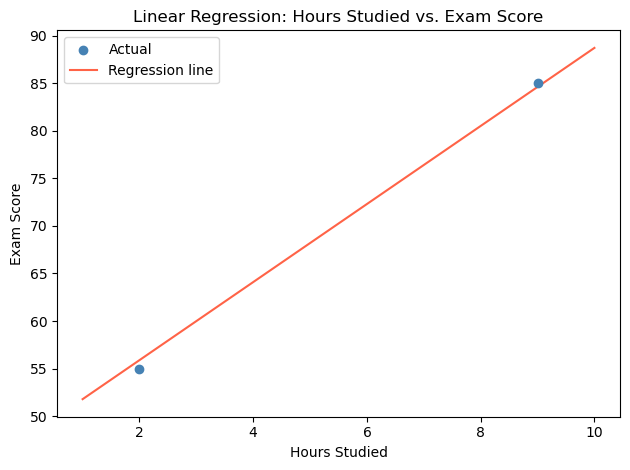

In [8]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')

plt.legend()
plt.tight_layout()
plt.show()

The actual data points follow the regression line closely, which shows that there is a strong positive relationship between hours studied and exam scores. The model appears to fit the data well.

## Lab 2
### Building your own model

In [9]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                          5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000,
                          9500, 10000],

    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                         12400, 13100, 14200, 15600, 15900, 17200, 18100,
                         19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [10]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


In [11]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [12]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
print(f"Slope (coefficient): {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

Slope (coefficient): 1.96
Intercept: 3625.89


The slope shows how much monthly revenue is expected to increase for every additional $1 spent on advertising.

### Making predictions and evaluating the model

In [14]:
y2_pred = model2.predict(X2_test)

print("Actual values:")
print(list(y2_test))

print("\nPredicted values:")
print(list(y2_pred.round(2)))

Actual values:
[4200, 21500, 19400, 5100]

Predicted values:
[np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [15]:
r2_score = model2.score(X2_test, y2_test)

print(f"R² score: {r2_score:.3f}")

R² score: 0.998


The R² score shows how well the regression model explains the relationship between advertising spend and revenue. A value close to 1 indicates that the model fits the data very well and explains most of the variation in revenue.

### Visualizing the results

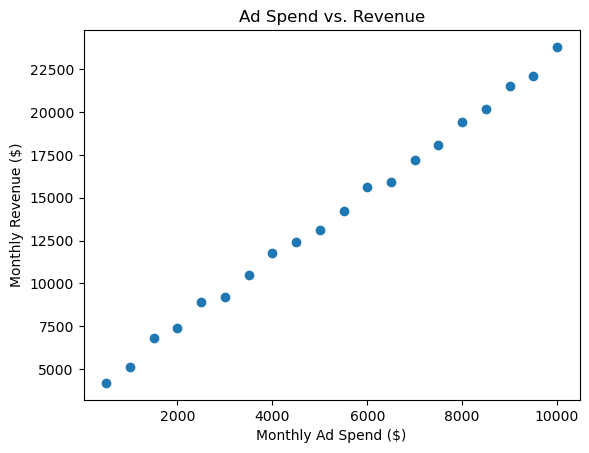

In [16]:
plt.scatter(X2, y2)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.show()

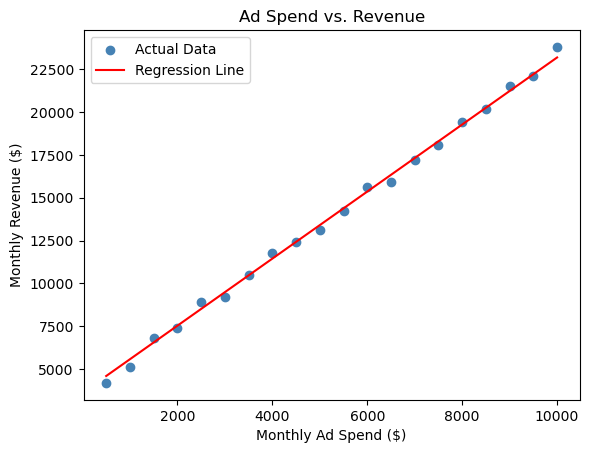

In [17]:
# Scatter plot
plt.scatter(X2, y2, color='steelblue', label='Actual Data')

# Regression line
plt.plot(X2, model2.predict(X2), color='red', label='Regression Line')

# Labels and title
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

# Legend
plt.legend()

plt.show()

The regression line appears to fit the data well because most of the data points are close to the line. This matches the R² score, which showed that the model explains most of the variation in revenue based on advertising spend.